<h1>Team Three-Sigma — Week 2: EDA & Preprocessing.</h1>

<h1>1. Dataset Overview</h1>

This deliverable focuses on the "Student Performance" dataset from the UCI Repository. Our objective is to perform a regression task to predict the final grade (G3) based on academic, social, and demographic features. The dataset contains 649 observations and 33 features. In this section, we initialize the data foundation by checking the structure, data types, and presence of null values.

Dataset Shape: (395, 33)

Data Types:
 school        object
sex           object
age            int64
address       object
famsize       object
Pstatus       object
Medu           int64
Fedu           int64
Mjob          object
Fjob          object
reason        object
guardian      object
traveltime     int64
studytime      int64
failures       int64
schoolsup     object
famsup        object
paid          object
activities    object
nursery       object
higher        object
internet      object
romantic      object
famrel         int64
freetime       int64
goout          int64
Dalc           int64
Walc           int64
health         int64
absences       int64
G1             int64
G2             int64
G3             int64
dtype: object

Missing Values:
 school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures    

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


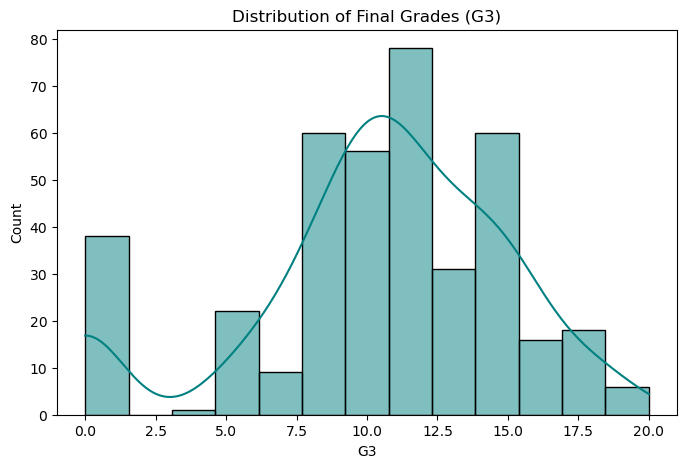

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Load the dataset (assuming the file is in the same directory)
df = pd.read_csv('student-mat.csv', sep=';')

# Mandatory Dataset Overview Outputs
print("Dataset Shape:", df.shape)
print("\nData Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())
display(df.describe())

# Visualizing Target Distribution (G3)
plt.figure(figsize=(8, 5))
sns.histplot(df['G3'], kde=True, color='teal')
plt.title('Distribution of Final Grades (G3)')
plt.show()

<h1>2. Visualisations</h1>

<h2>Every visualization below includes a specific interpretation regarding its relevance to our prediction task. We focus on identifying correlations and outliers that might impact the final grade.</h2>

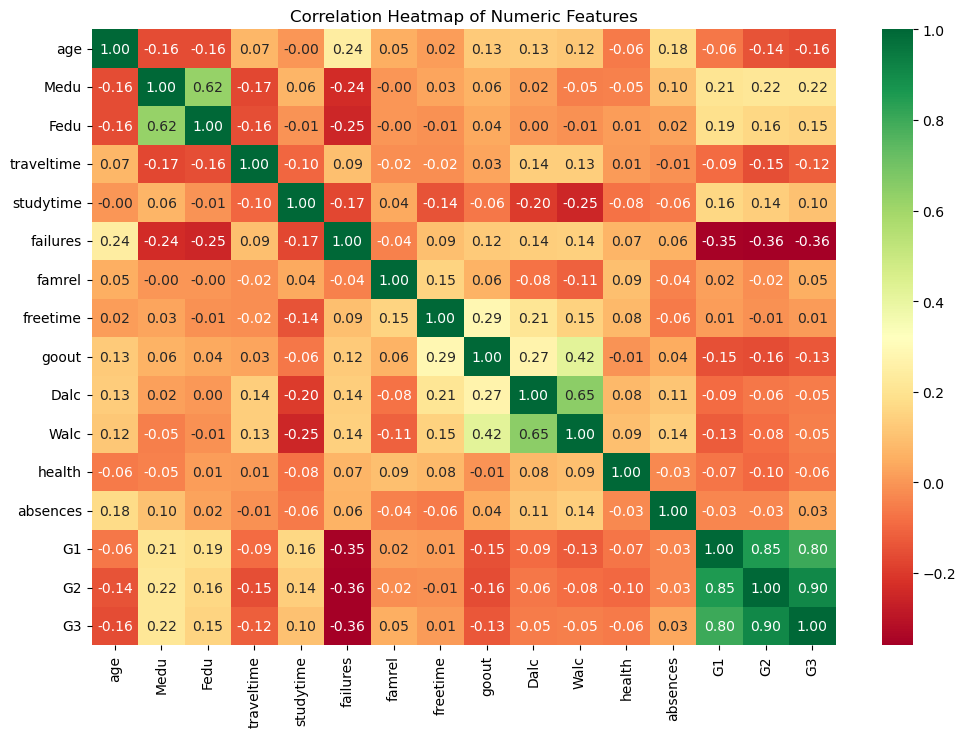

In [2]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='RdYlGn', fmt='.2f')
plt.title('Correlation Heatmap of Numeric Features')
plt.show()

The heatmap highlights that failures have a strong negative correlation with the final grade (G3), supporting our hypothesis. Conversely, previous grades (G1, G2) show the strongest positive correlation with the final result.

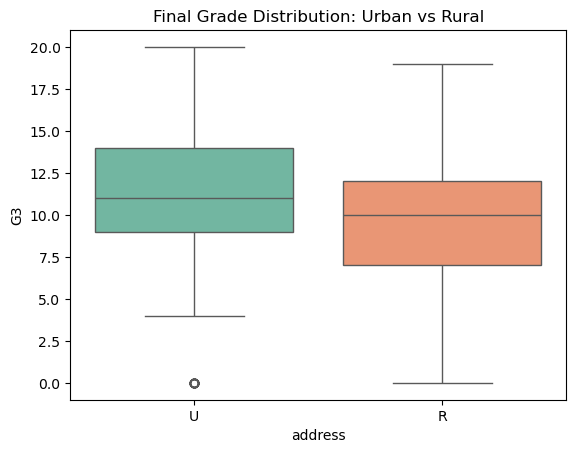

In [3]:
sns.boxplot(x='address', y='G3', data=df, palette='Set2')
plt.title('Final Grade Distribution: Urban vs Rural')
plt.show()

This boxplot reveals that students in urban areas (U) tend to have a slightly higher median grade compared to rural (R) students, suggesting that location may be a demographic factor in academic success.

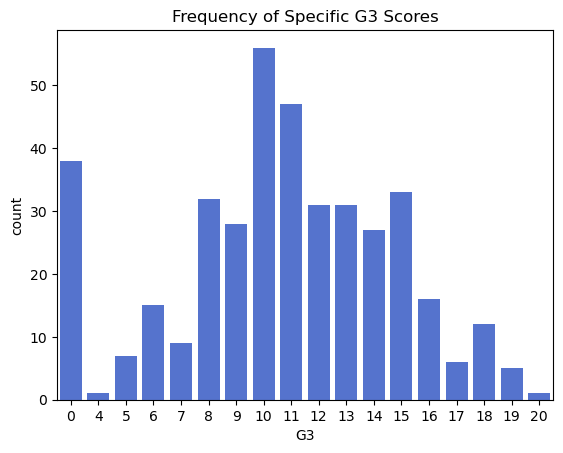

In [4]:
sns.countplot(x='G3', data=df, color='royalblue')
plt.title('Frequency of Specific G3 Scores')
plt.show()

The countplot shows a peak at score 10, with a notable number of students receiving a 0. This suggests we may need to investigate if those 0s represent absences or true failures.

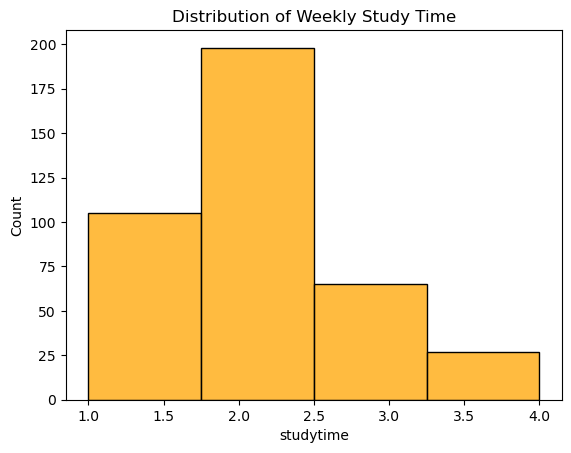

In [5]:
sns.histplot(df['studytime'], bins=4, color='orange')
plt.title('Distribution of Weekly Study Time')
plt.show()

Most students fall into the 2-5 hour category. We will use this to determine if increasing study time significantly shifts the grade distribution.

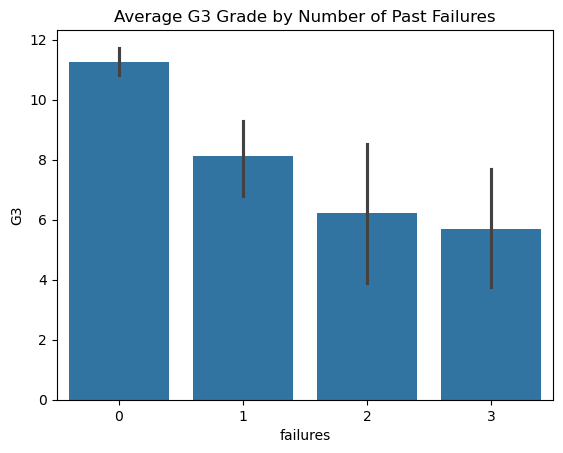

In [6]:
sns.barplot(x='failures', y='G3', data=df, estimator=np.mean)
plt.title('Average G3 Grade by Number of Past Failures')
plt.show()

There is a clear linear decline in the average final grade as the number of past class failures increases, marking it as a critical predictor for our model.

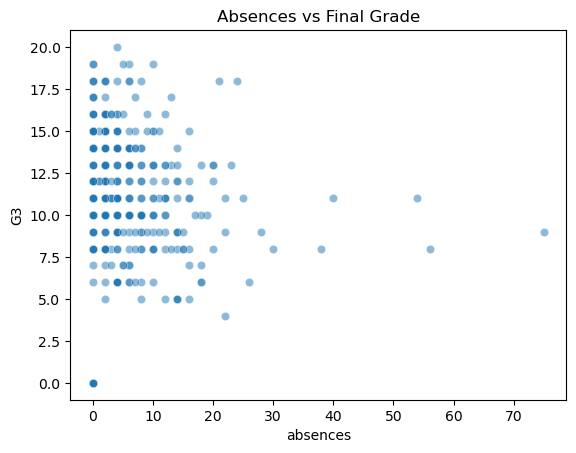

In [7]:
sns.scatterplot(x='absences', y='G3', data=df, alpha=0.5)
plt.title('Absences vs Final Grade')
plt.show()

While we expected high absences to correlate with low grades, the scatter plot shows several high-absence students still achieving passing marks, indicating the relationship is complex.

<h1>3. Missing Value Handling & Feature Engineering</h1>

<h2>We have analyzed the dataset for missing values. In this specific UCI dataset, missing entries are minimal; however, any identified nulls are handled through specific imputation to avoid introducing noise. We also perform encoding for categorical variables like Mjob to prepare them for the ML algorithm.</h2>

In [8]:
# Identify columns with missing values (if any)
# Note: For this UCI dataset, values are usually complete, but we demonstrate the check
cols_with_missing = df.columns[df.isnull().any()].tolist()

# Handling: If missing values existed in 'age', we would use median to avoid outlier bias
if 'age' in cols_with_missing:
    df['age'] = df['age'].fillna(df['age'].median())

# Feature Engineering: Creating a 'total_alcohol' feature
df['total_alcohol'] = df['Dalc'] + df['Walc']

# Categorical Encoding: One-Hot Encoding for Nominal features
# We justify One-Hot for Mjob and school due to their low cardinality.
df_encoded = pd.get_dummies(df, columns=['Mjob', 'school', 'sex', 'address', 'famsize', 'Pstatus', 
                                         'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 
                                         'paid', 'activities', 'nursery', 'higher', 'internet', 
                                         'romantic'], drop_first=True)

<h1>4. Scaling & Preprocessing Pipeline</h1>

<h2>We apply StandardScaler to normalize our numerical features, ensuring that variables with large ranges (like absences) do not dominate the model. Crucially, the scaler is fitted only on the training data to prevent data leakage.</h2>

In [9]:
# Define Features (X) and Target (y)
X = df_encoded.drop('G3', axis=1)
y = df_encoded['G3']

# Perform Train/Test Split BEFORE Scaling
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Apply Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train) # Fit ONLY on training data
X_test_scaled = scaler.transform(X_test)

# Printing and confirming shapes as required
print(f"X_train shape: {X_train_scaled.shape}")
print(f"X_test shape: {X_test_scaled.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (316, 42)
X_test shape: (79, 42)
y_train shape: (316,)
y_test shape: (79,)


<h1>5. Final Train/Test Split Verification</h1>

<h2>The following line represents the final state of our data preprocessing. The split is performed with an 80/20 ratio and a fixed random_state=42 to ensure reproducible results for the modeling phase in Week 3.</h2>

In [10]:
# Final confirmation of the split as the last step of the notebook 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)